In [1]:
import numpy as np
import pandas as pd
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pd.set_option("display.width",1000)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [2]:
df=pd.read_csv("autos.csv")
print(df.info())

print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 371528 entries, 0 to 371527
Data columns (total 21 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   index                371528 non-null  int64 
 1   dateCrawled          371528 non-null  object
 2   name                 371528 non-null  object
 3   seller               371528 non-null  object
 4   offerType            371528 non-null  object
 5   price                371528 non-null  int64 
 6   abtest               371528 non-null  object
 7   vehicleType          333659 non-null  object
 8   yearOfRegistration   371528 non-null  int64 
 9   gearbox              351319 non-null  object
 10  powerPS              371528 non-null  int64 
 11  model                351044 non-null  object
 12  kilometer            371528 non-null  int64 
 13  monthOfRegistration  371528 non-null  int64 
 14  fuelType             338142 non-null  object
 15  brand                371528 non-nu

In [3]:
#print(df['offerType'].unique())

df.drop(columns=["index","name","dateCrawled","offerType","dateCreated","nrOfPictures","postalCode","lastSeen","monthOfRegistration"],inplace=True)


#print( df.isnull().sum(), df.info())

# for column in df.select_dtypes("object"):
#     print(f"{column} : {df[column].unique()}")

df.dropna(inplace=True)
print(df.info())


<class 'pandas.core.frame.DataFrame'>
Index: 260956 entries, 3 to 371527
Data columns (total 12 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   seller              260956 non-null  object
 1   price               260956 non-null  int64 
 2   abtest              260956 non-null  object
 3   vehicleType         260956 non-null  object
 4   yearOfRegistration  260956 non-null  int64 
 5   gearbox             260956 non-null  object
 6   powerPS             260956 non-null  int64 
 7   model               260956 non-null  object
 8   kilometer           260956 non-null  int64 
 9   fuelType            260956 non-null  object
 10  brand               260956 non-null  object
 11  notRepairedDamage   260956 non-null  object
dtypes: int64(4), object(8)
memory usage: 25.9+ MB
None


In [4]:
for column in df.columns:
    print(f"{column} : {df[column].unique()}")

seller : ['privat' 'gewerblich']
price : [ 1500  3600   650 ...  1559 10985 14989]
abtest : ['test' 'control']
vehicleType : ['kleinwagen' 'limousine' 'cabrio' 'kombi' 'suv' 'bus' 'coupe' 'andere']
yearOfRegistration : [2001 2008 1995 2004 1980 2005 2011 2007 2009 2002 1997 1990 1981 2003
 1984 1999 1998 2012 2014 2006 2010 2000 1993 2013 1994 1991 1996 1989
 2015 1968 1992 1983 1959 1973 1969 1971 1987 1988 1967 2016 1986 1985
 1965 1945 1974 1979 1982 1978 1976 1972 1977 1966 1975 1970 1937 1963
 1936 1954 1961 1962 1960 1951 1964 1953 1957 1958 1956 2017 1950 1955
 1948 1932 1952 1931 2018 1949 1942 1910 1923 1930 1943 1938 1941 1934
 1919 1939 1929 1933 1947]
gearbox : ['manuell' 'automatik']
powerPS : [   75    69   102   109    50   105   140   190   136   160   231   118
   193    99    60   113   218   122   129    70    95   177     0   306
    61   101   232   156    80    82   204   155   150    87    86   131
   143   303   125   224   235   200   178   265   163    77   11

In [5]:
#outlier detection
for col in df.select_dtypes("int64"):
    q3=df[col].quantile(0.75)
    q1=df[col].quantile(0.25)
    IQR=q3-q1
    outliers=df[(df[col]< q1- 1.5*IQR) |(df[col]> q3 +1.5*IQR)]
    pct=len(outliers)/(len(df))*100
    print(f"{col} : {pct:.2f} %")
print(df.columns)

price : 6.58 %
yearOfRegistration : 1.30 %
powerPS : 3.61 %
kilometer : 3.16 %
Index(['seller', 'price', 'abtest', 'vehicleType', 'yearOfRegistration', 'gearbox', 'powerPS', 'model', 'kilometer', 'fuelType', 'brand', 'notRepairedDamage'], dtype='object')


In [6]:
# Cars with price <= 0 are not useful for price prediction
df = df[df["price"] > 0]

# Remove extremely expensive cars using a reasonable percentile
# This prevents a few extreme prices from dominating MSE.
upper_price = df["price"].quantile(0.99)

df = df[df["price"] <= upper_price]

print("\nAfter price filtering:")
print(df.shape)

print("\nPrice statistics:")
print(df["price"].describe())


After price filtering:
(254992, 12)

Price statistics:
count    254992.000000
mean       6241.351886
std        6573.304615
min           1.000000
25%        1599.000000
50%        3888.000000
75%        8500.000000
max       38750.000000
Name: price, dtype: float64


In [7]:
from sklearn.model_selection import train_test_split
X=df[['seller', 'abtest', 'vehicleType', 'yearOfRegistration', 'gearbox', 'powerPS', 'model', 'kilometer', 'fuelType', 'brand', 'notRepairedDamage']]
y=df["price"]
x_train,x_test,y_train,y_test =train_test_split(X,y,test_size=0.2,random_state=42)


In [8]:
df.head(5).to_csv("sample.csv")

In [9]:
encoded= {}
from sklearn.preprocessing import  OneHotEncoder

categorical_cols = x_train.select_dtypes(include="object").columns
print(categorical_cols)
encoder = OneHotEncoder(handle_unknown="ignore",sparse_output=False)

x_train_encoded = encoder.fit_transform(x_train[categorical_cols])

x_test_encoded = encoder.transform(x_test[categorical_cols])

# for col in df.columns:
#     print(f"{col} : {df[col].unique()}")
print(x_train_encoded)
print(x_test.info())

Index(['seller', 'abtest', 'vehicleType', 'gearbox', 'model', 'fuelType', 'brand', 'notRepairedDamage'], dtype='object')
[[0. 1. 1. ... 0. 0. 1.]
 [0. 1. 1. ... 0. 0. 1.]
 [0. 1. 1. ... 0. 0. 1.]
 ...
 [0. 1. 1. ... 0. 0. 1.]
 [0. 1. 0. ... 0. 0. 1.]
 [0. 1. 1. ... 0. 1. 0.]]
<class 'pandas.core.frame.DataFrame'>
Index: 50999 entries, 28731 to 296598
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   seller              50999 non-null  object
 1   abtest              50999 non-null  object
 2   vehicleType         50999 non-null  object
 3   yearOfRegistration  50999 non-null  int64 
 4   gearbox             50999 non-null  object
 5   powerPS             50999 non-null  int64 
 6   model               50999 non-null  object
 7   kilometer           50999 non-null  int64 
 8   fuelType            50999 non-null  object
 9   brand               50999 non-null  object
 10  notRepairedDamage   50999 non-nul

In [10]:
scaler=StandardScaler()
scaling={}

from sklearn.preprocessing import StandardScaler

numeric_cols = x_train.select_dtypes(include="number").columns

x_train_scaled=scaler.fit_transform(x_train[numeric_cols])
x_test_scaled=scaler.transform(x_test[numeric_cols])
    
print(x_train_scaled)
    

[[-1.61380923 -0.43938869 -1.1362262 ]
 [ 1.35750468 -0.13468621 -0.881397  ]
 [-0.0499598  -0.43938869 -0.881397  ]
 ...
 [-0.0499598   0.25804144  0.64757819]
 [ 0.73196491  1.15183538 -1.90071379]
 [ 0.41919502  0.10230461  0.64757819]]


In [11]:
x_train_processed = np.hstack(
    [x_train_encoded, x_train_scaled]
)

x_test_processed = np.hstack(
    [x_test_encoded, x_test_scaled]
)
print(x_train_processed)

[[ 0.          1.          1.         ... -1.61380923 -0.43938869
  -1.1362262 ]
 [ 0.          1.          1.         ...  1.35750468 -0.13468621
  -0.881397  ]
 [ 0.          1.          1.         ... -0.0499598  -0.43938869
  -0.881397  ]
 ...
 [ 0.          1.          1.         ... -0.0499598   0.25804144
   0.64757819]
 [ 0.          1.          0.         ...  0.73196491  1.15183538
  -1.90071379]
 [ 0.          1.          1.         ...  0.41919502  0.10230461
   0.64757819]]


In [12]:

x_train_tensor = torch.tensor(x_train_processed, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1).to(device)

x_test_tensor = torch.tensor(x_test_processed, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1).to(device)





In [13]:
from torch.utils.data import Dataset, DataLoader

class custom_dataset(Dataset):
    def __init__(self, features, labels):
        self.feature=features
        self.label=labels
    def __len__(self):
        return self.feature.shape[0]
    def __getitem__(self, index):
            return self.feature[index], self.label[index]
        
train_dataset=custom_dataset(x_train_tensor,y_train_tensor)
test_dataset=custom_dataset(x_test_tensor,y_test_tensor)
    
train_loader=DataLoader(train_dataset,batch_size=512,shuffle=True)
test_loader=DataLoader(test_dataset,batch_size=512, shuffle=True)   

In [14]:
                            # Model structure  creation 
import torch.nn as nn
class my_nn(nn.Module): 
    def __init__(self,input_features):
        super().__init__()
        self.model=nn.Sequential(
            nn.Linear(input_features,128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            
            nn.Linear(128,64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            
            nn.Linear(64,32),
            nn.ReLU(),
            
            nn.Linear(32,1)
            
        )
    def forward(self,x):
        return self.model(x)
        

In [15]:
print(x_train_tensor.shape[1])

314


In [16]:
#training pipeline
epoches=100
lr=0.001
model=my_nn(x_train_tensor.shape[1])
model=model.to(device)
criterion=nn.MSELoss()
optimizer=torch.optim.Adam(model.parameters(), lr=lr,weight_decay=1e-4)

In [17]:
for epoch in range(epoches):
    total_epoch_loss=0
    model.train()
    for batch_feature, batch_labels in train_loader:
        batch_feature , batch_labels = batch_feature.to(device), batch_labels.to(device)
        y_pred=model(batch_feature)
        
        loss=criterion(y_pred, batch_labels)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    #Model Evaluataton
        
        total_epoch_loss+=loss.item()
    avg_loss=total_epoch_loss/len(train_loader)
    print(f"Epoch :{epoch+1}, Loss :{avg_loss:.6f}")

Epoch :1, Loss :78146235.097744
Epoch :2, Loss :44363357.082707
Epoch :3, Loss :10198524.067043
Epoch :4, Loss :5041807.595865
Epoch :5, Loss :4683594.302005
Epoch :6, Loss :4579957.419173
Epoch :7, Loss :4511886.242481
Epoch :8, Loss :4488999.622807
Epoch :9, Loss :4456065.743734
Epoch :10, Loss :4446520.132206
Epoch :11, Loss :4353204.075815
Epoch :12, Loss :4343906.927318
Epoch :13, Loss :4319785.013158
Epoch :14, Loss :4324188.111529
Epoch :15, Loss :4312693.093985
Epoch :16, Loss :4250506.446115
Epoch :17, Loss :4257002.945489
Epoch :18, Loss :4256715.187343
Epoch :19, Loss :4229919.843985
Epoch :20, Loss :4202615.203008
Epoch :21, Loss :4185472.596491
Epoch :22, Loss :4176897.771617
Epoch :23, Loss :4154299.853383
Epoch :24, Loss :4153944.482456
Epoch :25, Loss :4169812.312030
Epoch :26, Loss :4124096.327068
Epoch :27, Loss :4128771.902256
Epoch :28, Loss :4094302.496241
Epoch :29, Loss :4121061.552632
Epoch :30, Loss :4089220.185777
Epoch :31, Loss :4056881.216165
Epoch :32, Los

In [18]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
model.eval()

predictions = []
actual_values = []

with torch.no_grad():

    for batch_features, batch_labels in test_loader:

        batch_features = batch_features.to(device)

        outputs = model(batch_features)

        predictions.extend(
            outputs.cpu().numpy().flatten()
        )

        actual_values.extend(
            batch_labels.cpu().numpy().flatten()
        )


# Convert to numpy
predictions = np.array(predictions)
actual_values = np.array(actual_values)


mae = mean_absolute_error(actual_values,predictions)
rmse = np.sqrt(mean_squared_error(actual_values,predictions))
r2 = r2_score(actual_values,predictions)

print("MODEL PERFORMANCE")
print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

MODEL PERFORMANCE
MAE : 1180.99853515625
RMSE: 2034.7452543254647
R²  : 0.9038987159729004


In [19]:
comparison = pd.DataFrame({
    "Actual Price": actual_values[:20],"Predicted Price": predictions[:20]
})

print("\nSample Predictions:")
print(comparison)



Sample Predictions:
    Actual Price  Predicted Price
0         3500.0      2802.866455
1         5500.0      4822.852051
2         3750.0      5569.217773
3        12500.0     13853.992188
4         3600.0      4258.123047
5         1650.0      1108.058228
6         5400.0      4778.378418
7        14800.0     17299.289062
8        11850.0      9158.258789
9         2899.0      4351.900391
10        3190.0      1959.842407
11        2999.0      3859.424072
12       22750.0     17279.863281
13        2500.0      1835.537231
14        1700.0      3826.791260
15        4000.0      5231.358887
16        1499.0      1655.661255
17        6800.0      7343.375488
18        3999.0      5149.875488
19        6999.0      6102.717285


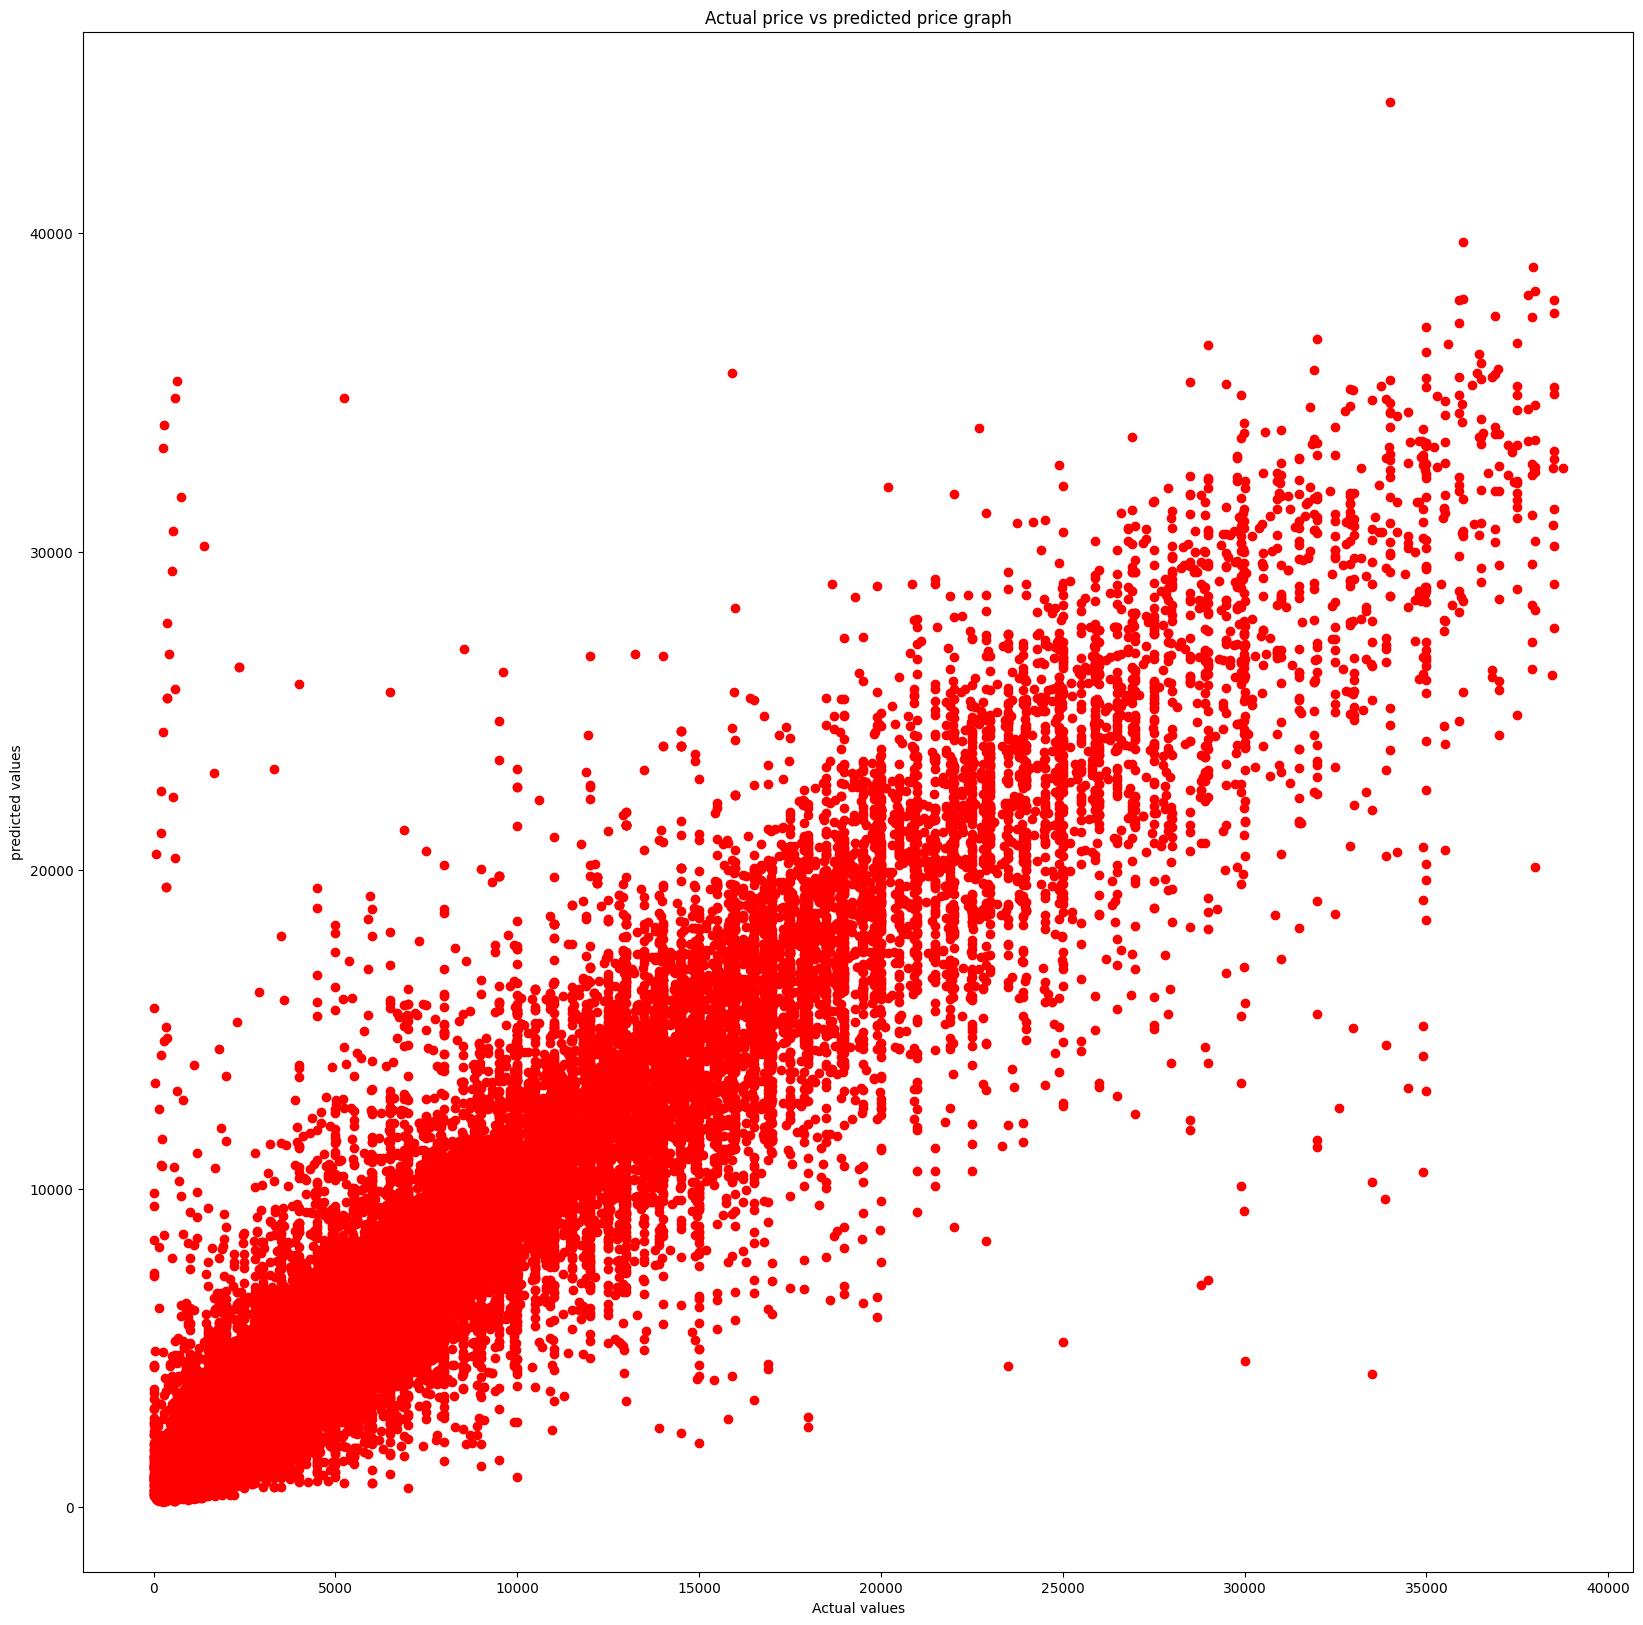

In [20]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(20,20))
plt.scatter(actual_values,predictions,color="red")
plt.xlabel('Actual values')
plt.ylabel("predicted values")
plt.title("Actual price vs predicted price graph")
plt.show()

In [21]:
def predict_car(car_data):
    car_df = pd.DataFrame([car_data])

              # categorical processing
    car_cat = encoder.transform(
        car_df[categorical_cols]
    )

         # numerical processing
    car_num = scaler.transform(
        car_df[numeric_cols]
    )

          # Combine
    car_processed = np.hstack([car_num, car_cat])

    # Tensor
    car_tensor = torch.tensor(
        car_processed,
        dtype=torch.float32
    ).to(device)

    # Prediction
    model.eval()

    with torch.no_grad():

        prediction = model(
            car_tensor
        )

    return prediction.item()






example_car = {
    "seller": "privat",
    "abtest": "test",
    "vehicleType": "limousine",
    "yearOfRegistration": 2010,
    "gearbox": "manuell",
    "powerPS": 180,
    "model": "golf",
    "kilometer": 10000,
    "fuelType": "benzin",
    "brand": "volkswagen",
    "notRepairedDamage": "nein"
}

predicted_price = predict_car(example_car)

print(f"\nPredicted price: {predicted_price:.2f}")


Predicted price: 3519.64


In [22]:

import joblib


torch.save(model.state_dict(), "car_price.pth")

joblib.dump(list(X.columns), "car_price_features.joblib")
joblib.dump(encoder, "car_price_encoder.joblib")                # fitted OneHotEncoder
joblib.dump(scaler, "car_price_scaler.joblib")                  # fitted StandardScaler
joblib.dump(list(categorical_cols), "car_price_categorical_cols.joblib")
joblib.dump(list(numeric_cols), "car_price_numeric_cols.joblib")





['car_price_numeric_cols.joblib']